# Comparativa Titanic vs Sewol
**TFE — Supervivencia en Desastres Marítimos**

Análisis comparativo de supervivencia entre el Titanic (1912) y el Sewol (2014).

## Paso 1 — Carga de los datasets

Cargamos los dos datasets y mostramos todas las columnas y las primeras filas para verificar que se leen correctamente.

In [8]:
import pandas as pd

titanic = pd.read_csv('../output/titanic_enriched.csv')
sewol = pd.read_csv('../sewol/sewol_eng.csv')

print('Titanic - shape:', titanic.shape)
print('Columnes:', list(titanic.columns))
print()
display(titanic.head())

print()
print('Sewol - shape:', sewol.shape)
print('Columnes:', list(sewol.columns))
print()
display(sewol.head())


Titanic - shape: (1309, 22)
Columnes: ['PassengerId', 'Name', 'Split', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'FamilyCat', 'AgeGroup', 'FareBand', 'HasCabin', 'Deck', 'SurvivalProb', 'DeathProb', 'ModelPred']



,PassengerId,Name,Split,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,...,FamilySize,IsAlone,FamilyCat,AgeGroup,FareBand,HasCabin,Deck,SurvivalProb,DeathProb,ModelPred
0,1,"Braund, Mr. Owen Harris",train,0.0,3,male,22.0,1,0,7.2500,...,2,0,Familia pequeña,Adulto joven,Bajo,0,Unknown,0.166230,0.833770,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",train,1.0,1,female,38.0,1,0,71.2833,...,2,0,Familia pequeña,Adulto,Alto,1,C,0.994789,0.005211,1
2,3,"Heikkinen, Miss. Laina",train,1.0,3,female,26.0,0,0,7.9250,...,1,1,Solo,Adulto joven,Medio-bajo,0,Unknown,0.407632,0.592368,0
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",train,1.0,1,female,35.0,1,0,53.1000,...,2,0,Familia pequeña,Adulto joven,Alto,1,C,0.985435,0.014565,1
4,5,"Allen, Mr. William Henry",train,0.0,3,male,35.0,0,0,8.0500,...,1,1,Solo,Adulto joven,Medio-bajo,0,Unknown,0.106616,0.893384,0



Sewol - shape: (476, 9)
Columnes: ['Unnamed: 0', 'Category-1', 'Category-2', 'Category-3', 'floor', 'location', 'Raw', 'gender', 'age']



,Unnamed: 0,Category-1,Category-2,Category-3,floor,location,Raw,gender,age
0,0,sailor,Deck,Captain,5,front,survival,male,69.0
1,1,sailor,Deck,1st voyage,5,front,survival,male,42.0
2,2,sailor,Deck,"1, etc.",5,front,survival,male,34.0
3,3,sailor,Deck,2nd saver,5,front,survival,male,47.0
4,4,sailor,Deck,"3,",5,front,survival,female,26.0


## Paso 2 — Normalización de los datasets

Creamos un DataFrame unificado con las columnas equivalentes de los dos desastres:

| Columna | Descripción |
|---------|-------------|
| `disaster` | Origen del registro: `titanic` o `sewol` |
| `gender` | Género: `male` / `female` |
| `age` | Edad en años |
| `survived` | 0 = no sobrevivió, 1 = sobrevivió |
| `role` | `passenger` o `crew` (tripulación) |

**Nota sobre `role`:** El dataset del Titanic cubre exclusivamente pasajeros. En el Sewol, los registros con `Category-1 == 'sailor'` corresponden a tripulación y se clasifican como `crew`; el resto (`student`, `Normal`) como `passenger`.

**Nota sobre el Titanic:** Usamos solo los 891 pasajeros del conjunto `train`, que tienen el valor real de `Survived`. Los 418 del conjunto `test` no tienen este valor y no se utilizan para la comparativa.

In [9]:
# Normalitzar Titanic (nomes train - 891 passatgers amb Survived real)
titanic_train = titanic[titanic['Split'] == 'train'].copy()

titanic_norm = pd.DataFrame({
    'disaster': 'titanic',
    'gender':   titanic_train['Sex'],
    'age':      titanic_train['Age'],
    'survived': titanic_train['Survived'].astype(float),
    'role':     'passenger'
})

# Normalitzar Sewol
sewol_norm = pd.DataFrame({
    'disaster': 'sewol',
    'gender':   sewol['gender'],
    'age':      sewol['age'],
    'survived': sewol['Raw'].map({'survival': 1, 'Dead': 0}).astype(float),
    'role':     sewol['Category-1'].apply(lambda x: 'crew' if x == 'sailor' else 'passenger')
})

# Imputar nuls d'edat del Sewol amb la mediana del Sewol
sewol_median_age = sewol_norm['age'].median()
sewol_norm['age'] = sewol_norm['age'].fillna(sewol_median_age)
print(f'Mediana edat Sewol (usada per imputar nuls): {sewol_median_age:.1f} anys')

# Unir els dos datasets
combined = pd.concat([titanic_norm, sewol_norm], ignore_index=True)

print()
print('Dataset combinat - shape:', combined.shape)
print(f'  - Titanic (train): {len(titanic_norm)} passatgers')
print(f'  - Sewol:           {len(sewol_norm)} persones')
print()
print('Valors nuls per columna (han de ser 0):')
print(combined.isnull().sum())
print()
display(combined.head(10))


Mediana edat Sewol (usada per imputar nuls): 17.0 anys

Dataset combinat - shape: (1367, 5)
  - Titanic (train): 891 passatgers
  - Sewol:           476 persones

Valors nuls per columna (han de ser 0):
disaster    0
gender      0
age         0
survived    0
role        0
dtype: int64



,disaster,gender,age,survived,role
0,titanic,male,22.0,0.0,passenger
1,titanic,female,38.0,1.0,passenger
2,titanic,female,26.0,1.0,passenger
3,titanic,female,35.0,1.0,passenger
4,titanic,male,35.0,0.0,passenger
5,titanic,male,26.0,0.0,passenger
6,titanic,male,54.0,0.0,passenger
7,titanic,male,2.0,0.0,passenger
8,titanic,female,27.0,1.0,passenger
9,titanic,female,14.0,1.0,passenger


## Paso 3 — Análisis de supervivencia por género

Calculamos la tasa de supervivencia por género en cada desastre. Esta es la comparativa central del TFE.

Trabajamos **solo con pasajeros** (`role == 'passenger'`) para hacer una comparación justa: el Titanic no tiene tripulación en el dataset y no tiene sentido comparar pasajeros del Titanic con tripulantes del Sewol.

### 3.1 Tabla de tasas de supervivencia

Filtramos los pasajeros y calculamos, para cada combinación de desastre y género:
- Cuántas personas había en total
- Cuántas sobrevivieron
- El porcentaje de supervivencia

In [10]:
# Filtrem nomes passatgers
passengers = combined[combined['role'] == 'passenger'].copy()

# Calculem total, supervivents i taxa per desastre i genere
survival_table = passengers.groupby(['disaster', 'gender']).agg(
    total    = ('survived', 'count'),
    survived = ('survived', 'sum')
).reset_index()

survival_table['survival_rate'] = (survival_table['survived'] / survival_table['total'] * 100).round(1)

print('Taxa de supervivencia per genere i desastre (nomes passatgers):')
print()
display(survival_table)


Taxa de supervivencia per genere i desastre (nomes passatgers):



,disaster,gender,total,survived,survival_rate
0,sewol,female,182,53.0,29.1
1,sewol,male,261,96.0,36.8
2,titanic,female,314,233.0,74.2
3,titanic,male,577,109.0,18.9


### 3.2 Gráfico comparativo

Visualizamos las tasas de supervivencia en un gráfico de barras agrupadas: un grupo por género, dos barras por desastre. Esto permite ver de un vistazo si el patrón 'mujeres primero' se repite en el Sewol o cambia.

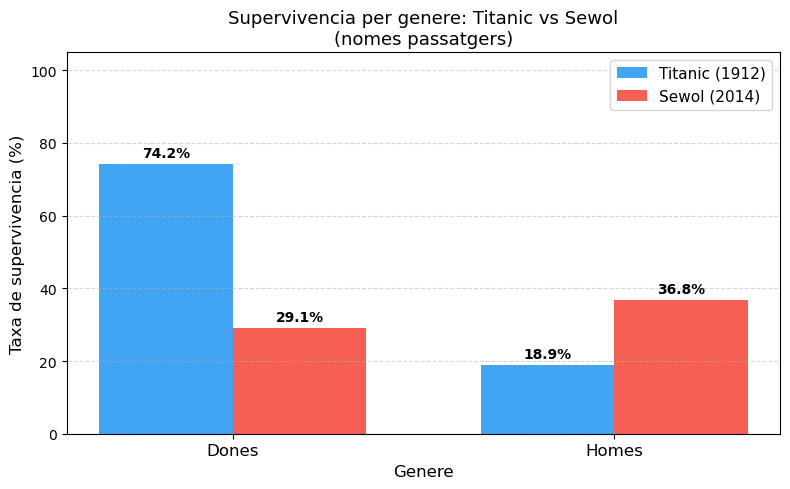

Grafic guardat a output/comparativa_genere_titanic_sewol.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

disasters = ['titanic', 'sewol']
genders   = ['female', 'male']
colors    = {'titanic': '#2196F3', 'sewol': '#F44336'}
labels    = {'titanic': 'Titanic (1912)', 'sewol': 'Sewol (2014)'}

x     = np.arange(len(genders))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

for i, disaster in enumerate(disasters):
    rates = [
        survival_table.loc[
            (survival_table['disaster'] == disaster) &
            (survival_table['gender'] == g), 'survival_rate'
        ].values[0]
        for g in genders
    ]
    bars = ax.bar(x + (i - 0.5) * width, rates, width,
                  label=labels[disaster], color=colors[disaster], alpha=0.85)
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{rate}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Genere', fontsize=12)
ax.set_ylabel('Taxa de supervivencia (%)', fontsize=12)
ax.set_title('Supervivencia per genere: Titanic vs Sewol\n(nomes passatgers)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(['Dones', 'Homes'], fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../output/comparativa_genere_titanic_sewol.png', dpi=150)
plt.show()
print('Grafic guardat a output/comparativa_genere_titanic_sewol.png')


## Paso 4 — Análisis de supervivencia por edad

Analizamos si la edad tuvo un impacto diferente en los dos desastres.

El Sewol tiene una distribución de edad muy diferente al Titanic: el 69% de sus pasajeros tenían entre 10 y 20 años (estudiantes de instituto). Por este motivo, definimos grupos de edad específicos para esta comparativa, sin modificar ninguno de los datos anteriores.

### 4.1 Creación de los grupos de edad

Definimos 5 grupos adaptados a la distribución del Sewol. Los creamos en una copia local del DataFrame `passengers` para no modificar nada de lo que ya tenemos.

In [12]:
# Treballem amb una copia local - no toquem el DataFrame combined
passengers_age = passengers.copy()

bins        = [0, 13, 20, 40, 60, 100]
age_labels  = ['Nen (0-12)', 'Adolescent (13-19)', 'Adult jove (20-39)', 'Adult (40-59)', 'Gran (60+)']

passengers_age['age_group'] = pd.cut(passengers_age['age'], bins=bins, labels=age_labels, right=False)

print('Distribucio per grup d\'edat:')
print()
display(passengers_age.groupby(['disaster', 'age_group'], observed=True).size().unstack(fill_value=0))


Distribucio per grup d'edat:



age_group,Nen (0-12),Adolescent (13-19),Adult jove (20-39),Adult (40-59),Gran (60+)
disaster,,,,,
sewol,4,335,23,55,26
titanic,73,128,498,166,26


### 4.2 Tasa de supervivencia por grupo de edad

Calculamos la tasa de supervivencia de cada grupo de edad en cada desastre. Esto nos permite ver si los adolescentes del Sewol tuvieron una tasa diferente a la de otros grupos, y compararlo con el mismo grupo en el Titanic.

In [15]:
age_table = passengers_age.groupby(['disaster', 'age_group'], observed=True).agg(
    total    = ('survived', 'count'),
    survived = ('survived', 'sum')
).reset_index()

age_table['survival_rate'] = (age_table['survived'] / age_table['total'] * 100).round(1)

print('Taxa de supervivencia per grup d\'edat i desastre:')
print()
display(age_table)
print()
print(age_table.to_string(index=False))


Taxa de supervivencia per grup d'edat i desastre:



,disaster,age_group,total,survived,survival_rate
0,sewol,Nen (0-12),4,2.0,50.0
1,sewol,Adolescent (13-19),335,80.0,23.9
2,sewol,Adult jove (20-39),23,12.0,52.2
3,sewol,Adult (40-59),55,43.0,78.2
4,sewol,Gran (60+),26,12.0,46.2
5,titanic,Nen (0-12),73,42.0,57.5
6,titanic,Adolescent (13-19),128,58.0,45.3
7,titanic,Adult jove (20-39),498,168.0,33.7
8,titanic,Adult (40-59),166,67.0,40.4
9,titanic,Gran (60+),26,7.0,26.9



disaster          age_group  total  survived  survival_rate
   sewol         Nen (0-12)      4       2.0           50.0
   sewol Adolescent (13-19)    335      80.0           23.9
   sewol Adult jove (20-39)     23      12.0           52.2
   sewol      Adult (40-59)     55      43.0           78.2
   sewol         Gran (60+)     26      12.0           46.2
 titanic         Nen (0-12)     73      42.0           57.5
 titanic Adolescent (13-19)    128      58.0           45.3
 titanic Adult jove (20-39)    498     168.0           33.7
 titanic      Adult (40-59)    166      67.0           40.4
 titanic         Gran (60+)     26       7.0           26.9


### 4.3 Gráfico comparativo por grupo de edad

Visualizamos las tasas de supervivencia por grupo de edad en un gráfico de líneas. Las líneas permiten ver fácilmente si el patrón de edad es similar o diverge entre los dos desastres.

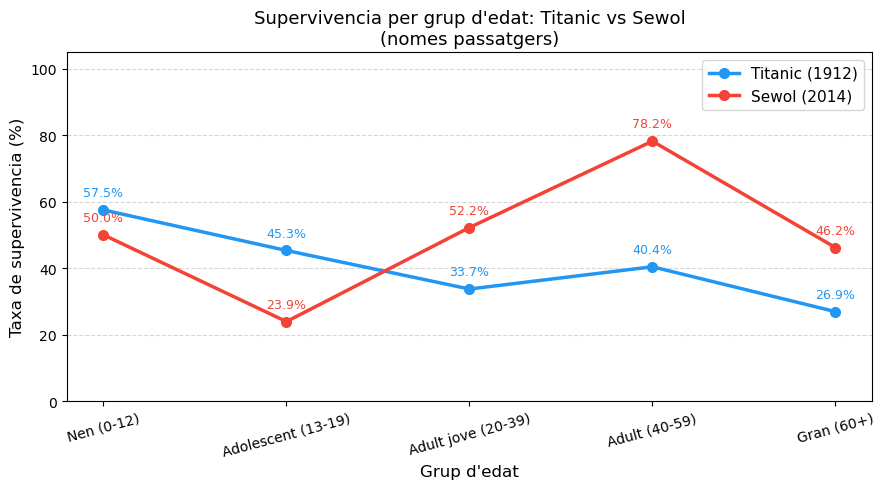

Grafic guardat a output/comparativa_edat_titanic_sewol.png


In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

for disaster, color, label in [('titanic', '#2196F3', 'Titanic (1912)'), ('sewol', '#F44336', 'Sewol (2014)')]:
    subset = age_table[age_table['disaster'] == disaster]
    ax.plot(subset['age_group'].astype(str), subset['survival_rate'],
            marker='o', linewidth=2.5, markersize=7, color=color, label=label)
    for _, row in subset.iterrows():
        ax.annotate(f"{row['survival_rate']}%",
                    (str(row['age_group']), row['survival_rate']),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9, color=color)

ax.set_xlabel('Grup d\'edat', fontsize=12)
ax.set_ylabel('Taxa de supervivencia (%)', fontsize=12)
ax.set_title('Supervivencia per grup d\'edat: Titanic vs Sewol\n(nomes passatgers)', fontsize=13)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../output/comparativa_edat_titanic_sewol.png', dpi=150)
plt.show()
print('Grafic guardat a output/comparativa_edat_titanic_sewol.png')


## Verificación — Niños en el Sewol

Comprobamos cuántos niños (0-12 años) hay en el Sewol y si su tasa de supervivencia es estadísticamente significativa.

In [18]:
for disaster in ['titanic', 'sewol']:
    d = passengers[passengers['disaster'] == disaster]
    nens = d[d['age'] < 13]
    print(f'{disaster.upper()}')
    print(f'  Total nens (0-12): {len(nens)}')
    print(f'  Supervivents: {int(nens["survived"].sum())}')
    print(f'  Taxa: {nens["survived"].mean()*100:.1f}%')
    print(f'  Detall edats: {sorted(nens["age"].tolist())}')
    print()

TITANIC
  Total nens (0-12): 73
  Supervivents: 42
  Taxa: 57.5%
  Detall edats: [0.42, 0.67, 0.75, 0.75, 0.83, 0.83, 0.92, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 5.0, 5.0, 5.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 7.0, 7.0, 7.0, 8.0, 8.0, 8.0, 8.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 10.0, 10.0, 11.0, 11.0, 11.0, 11.0, 12.0]

SEWOL
  Total nens (0-12): 4
  Supervivents: 2
  Taxa: 50.0%
  Detall edats: [5.0, 7.0, 7.0, 11.0]



## Paso 5 — Guardar el dataset combinado

Guardamos el DataFrame `combined` como CSV en la carpeta `output/`. Este fichero será el punto de partida para las conclusiones y la tabla comparativa final.

In [17]:
combined.to_csv('../output/comparativa_titanic_sewol.csv', index=False)

print('Fitxer guardat: output/comparativa_titanic_sewol.csv')
print(f'Total registres: {len(combined)}')
print(f'  - Titanic (train): {len(combined[combined["disaster"] == "titanic"])}')
print(f'  - Sewol:           {len(combined[combined["disaster"] == "sewol"])}')
print()
print('Columnes:', list(combined.columns))

Fitxer guardat: output/comparativa_titanic_sewol.csv
Total registres: 1367
  - Titanic (train): 891
  - Sewol:           476

Columnes: ['disaster', 'gender', 'age', 'survived', 'role']
